# 03 — Local SLM Battery Control · Google Colab

**Phase 2 / Month 2** · MSc Thesis — ECLIPSE project  
Supervisor: Dr. Panagiotis Kasnesis | Student: Antonios Bastoulis

---

This notebook runs the language model **locally on the Colab GPU** instead of making
remote API calls. It is fully self-contained: all state rendering, action parsing,
prompt definitions, and rollout logic are defined inline.

The **only** external dependency is `src/env.py` (CityLearn wrappers, reward functions)
— the stable infrastructure promoted from Phase 1.

| Approach | Model | Latency / call | 168-step rollout |
|----------|-------|----------------|------------------|
| `02` Remote API | claude-haiku / deepseek-chat | 0.5–3 s | **1–2 hours** |
| **`03` Local SLM** | Qwen2.5-1.5B (T4) | ~0.3 s | **~2 minutes** |
| **`03` Local SLM** | Qwen3-4B (T4) | ~0.8 s | **~5 minutes** |

**Setup:** Runtime → Change runtime type → **T4 GPU** (free tier).  
Fill in `GITHUB_REPO` in § 0, then **Run All**.

**Dual-agent setup:**

| Agent | Buildings | Observability |
|-------|-----------|---------------|
| **α** | B0, B1, B2 | Sees only its 3 buildings |
| **β** | B3, B4, B5 | Sees only its 3 buildings |

Both agents share the same model weights — inference is serial (α then β) with no crosstalk.

**Prompt philosophy:** `make_minimal_prompt` — task context + state variable meanings +
output format only. No prescribed rules. We let the SLM develop its own strategy.

## § 0 — Runtime & Config
> **Edit this cell only.** Nothing else needs changing.

In [1]:
import os, sys, subprocess, time, warnings, json, random
import numpy as np

# ── Runtime check ─────────────────────────────────────────────────────────
try:
    import torch
    if torch.cuda.is_available():
        _gpu  = torch.cuda.get_device_name(0)
        _vram = torch.cuda.get_device_properties(0).total_memory / 1e9
        print(f"✓ GPU: {_gpu}  ({_vram:.1f} GB VRAM)")
    else:
        print("⚠  No GPU — set Runtime → Change runtime type → T4 GPU")
except ImportError:
    print("torch not yet installed — will be in § 1")

# ── Model selection ────────────────────────────────────────────────────────
MODEL_ID:     str  = "google/gemma-4-E4B-it"
#Qwen/Qwen3-4B-Instruct-2507 good results
LOAD_IN_4BIT: bool = True    # required for 8B models on T4 (15 GB VRAM)

# MAX_NEW_TOKENS: budget per LLM call.
MAX_NEW_TOKENS: int = 400

# ── HuggingFace token (only needed for gated models like Llama) ───────────
HF_TOKEN: str  = os.environ.get("HF_TOKEN")

# ── GitHub repo URL ───────────────────────────────────────────────────────
GITHUB_REPO: str = "https://github.com/antonisbast/eclipse-thesis"

# ── Experiment window (matches 02_llm_policy for direct comparison) ───────
WEEK_START: int = 3624
WEEK_LEN:   int = 168  # 1 week in hours

# ── Dual-agent split ──────────────────────────────────────────────────────
AGENT_A_BUILDINGS: list = [0, 1, 2]
AGENT_B_BUILDINGS: list = [3, 4, 5]

# ── Local output ──────────────────────────────────────────────────────────
LOCAL_OUTDIR: str = "/content/eclipse-thesis/notebooks/artifacts"
os.makedirs(LOCAL_OUTDIR, exist_ok=True)

print(f"\nModel          : {MODEL_ID}")
print(f"4-bit quant    : {LOAD_IN_4BIT}")
print(f"Max new tokens : {MAX_NEW_TOKENS}")
print(f"Window         : t{WEEK_START}..{WEEK_START + WEEK_LEN - 1} ({WEEK_LEN} steps)")
print(f"Agents         : α={AGENT_A_BUILDINGS}  β={AGENT_B_BUILDINGS}")


✓ GPU: Tesla T4  (15.6 GB VRAM)

Model          : google/gemma-4-E4B-it
4-bit quant    : True
Max new tokens : 400
Window         : t3624..3791 (168 steps)
Agents         : α=[0, 1, 2]  β=[3, 4, 5]


## § 1 — Install Dependencies

In [2]:
# Step 1 — CityLearn dependencies (must install before citylearn itself)
# doe-xstock and nrel-pysam are CityLearn data-layer deps that pip won't
# resolve correctly if installed together with citylearn in one shot.
!pip install numpy gymnasium doe-xstock nrel-pysam -q
# Step 2 — CityLearn without letting pip touch the deps it just resolved
!pip install CityLearn --no-deps -q
print("✓ CityLearn installed")

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.3/47.3 MB 15.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 77.1/77.1 MB 9.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.7/8.7 MB 72.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 107.7/107.7 kB 7.4 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
ipython 7.34.0 requires jedi>=0.16, which is not installed.
moviepy 1.0.3 requires decorator<5.0,>=4.0.2, but you have decorator 5.2.1 which is incompatible.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 398.5/398.5 kB 32.0 MB/s eta 0:00:00
✓ CityLearn installed


In [3]:
# Step 3 — ML stack (transformers, quantization, GPU acceleration)
# Installing transformers from GitHub source to support new architectures like gemma4
!pip install -q --upgrade git+https://github.com/huggingface/transformers.git accelerate bitsandbytes
print("✓ ML dependencies installed")

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 10.1 MB/s eta 0:00:00
✓ ML dependencies installed


## § 2 — Clone Repository

This pulls `src/env.py` and `src/agent.py` from your GitHub repo.  

> **Alternative if you haven't pushed yet:** upload `src/env.py` and `src/agent.py`
> via the Colab Files panel (left sidebar → upload icon) into `/content/src/`,
> then replace `REPO_DIR` below with `"/content"` and skip the `git clone` block.

In [4]:
# ── Fresh clone utility ───────────────────────────────────────────────────
# Run this cell ONLY if you want to discard the local repo and re-clone from
# GitHub (e.g. after pushing new commits). Skip it on a normal Run All.
!rm -rf /content/eclipse-thesis
print("Repo directory removed — run the clone-repo cell (§ 2) next.")

Repo directory removed — run the clone-repo cell (§ 2) next.


In [5]:
REPO_DIR = "/content/eclipse-thesis"

if not os.path.exists(REPO_DIR):
    result = subprocess.run(
        ["git", "clone", GITHUB_REPO, REPO_DIR],
        capture_output=True, text=True,
    )
    print(result.stdout or result.stderr)
else:
    result = subprocess.run(
        ["git", "-C", REPO_DIR, "pull"],
        capture_output=True, text=True,
    )
    print("Repo already present —", result.stdout.strip() or "up to date")

if REPO_DIR not in sys.path:
    sys.path.insert(0, REPO_DIR)
print(f"sys.path ← {REPO_DIR}")

# HuggingFace login (only for gated models like Llama)
if HF_TOKEN:
    from huggingface_hub import login
    login(token=HF_TOKEN, add_to_git_credential=False)
    print("✓ HuggingFace login OK")

Cloning into '/content/eclipse-thesis'...

sys.path ← /content/eclipse-thesis


In [6]:
# ── Verify paths (debug) ──────────────────────────────────────────────────
import os, sys
print("Contents of /content/eclipse-thesis:")
try:
    print(os.listdir("/content/eclipse-thesis"))
except FileNotFoundError:
    print("  ✗ Directory not found — did the clone succeed?")

print(f"\nsys.path[0]: {sys.path[0]}")
print(f"src/ present: {os.path.isdir('/content/eclipse-thesis/src')}")

Contents of /content/eclipse-thesis:
['.DS_Store', 'configs', '.gitignore', 'notebooks', 'data', 'docs', 'requirements.txt', 'gitignore', 'CLAUDE.md', '.vscode', '.git', 'src', 'README.md']

sys.path[0]: /content/eclipse-thesis
src/ present: True


## § 3 — Imports & Environment Factory

Imports from `src/env.py` only — the proven, stable env infrastructure from Phase 1.
Everything else (state rendering, action parsing, prompts, rollout logic) is defined
inline in this notebook so we can iterate freely without touching `src/`.

`make_colab_env()` is a Colab-friendly variant of `src.env.make_env()`.
It passes the dataset name as a string to `CityLearnEnv`, triggering an automatic
download (~50 MB) on first call. Subsequent calls use the Colab cache.

In [7]:
import logging
import pandas as pd
import matplotlib.pyplot as plt
import citylearn
from citylearn.citylearn import CityLearnEnv

from src.env import (
    SEED, BUILDINGS, snapshot_state,
    MERLINReward, EcoPeakBatteryReward,
    OBSERVATIONS_LLM, OBSERVATIONS_SAC, ACTIVE_ACTIONS,
)

warnings.filterwarnings("ignore")
np.random.seed(SEED)
random.seed(SEED)

print(f"CityLearn {citylearn.__version__}")
print("src.env loaded.")


def make_colab_env(
    start: int = 0,
    end: int = 8758,
    obs_set: str = "llm",
    reward_fn: str = "merlin",
    buildings=None,
) -> CityLearnEnv:
    """Colab variant of src.env.make_env() — uses CityLearn auto-download schema.

    Passing the dataset name as a string triggers a one-time download.
    All other parameters match make_env().
    """
    observations = OBSERVATIONS_SAC if obs_set == "sac" else OBSERVATIONS_LLM
    env = CityLearnEnv(
        schema="citylearn_challenge_2022_phase_all",
        buildings=buildings if buildings is not None else BUILDINGS,
        central_agent=False,
        active_actions=ACTIVE_ACTIONS,
        active_observations=observations,
        random_seed=SEED,
        simulation_start_time_step=start,
        simulation_end_time_step=end,
    )
    env.reward_function = (
        EcoPeakBatteryReward(env.get_metadata()) if reward_fn == "eco"
        else MERLINReward(env.get_metadata())
    )
    return env


print("make_colab_env() ready.")
print("Note: first call downloads the dataset (~50 MB) — ~30 s on Colab.")

CityLearn 2.5.0
src.env loaded.
make_colab_env() ready.
Note: first call downloads the dataset (~50 MB) — ~30 s on Colab.


In [8]:
import re
import numpy as np

# ── Thresholds ─────────────────────────────────────────────────────────────
PRICE_PEAK_THRESHOLD      = 0.30   # $/kWh — above this = PEAK price
IRRADIANCE_LOW_THRESHOLD  = 50     # W/m²  — below this = NONE
IRRADIANCE_HIGH_THRESHOLD = 600    # W/m²  — above this = HIGH


def price_bucket(v: float | None) -> str:
    if v is None: return "?"
    return "PEAK" if v >= PRICE_PEAK_THRESHOLD else "LOW"

def carbon_bucket(v: float | None) -> str:
    if v is None: return "?"
    if v < 0.12: return "LOW"
    if v < 0.25: return "MID"
    return "HIGH"

def solar_bucket(v: float | None) -> str:
    if v is None: return "?"
    if v <= 0.0: return "NONE"
    if v < 0.5: return "LOW"
    return "HIGH"

def irradiance_bucket(v: float | None) -> str:
    if v is None: return "?"
    if v < IRRADIANCE_LOW_THRESHOLD: return "NONE"
    if v < IRRADIANCE_HIGH_THRESHOLD: return "LOW"
    return "HIGH"

def render_state(snap: list[dict]) -> str:
    """Convert a snapshot (list of building dicts) into an LLM prompt string."""
    if not snap:
        return "(empty snapshot)"
    d0   = snap[0]
    # CityLearn provides 'hour' (1-24) and 'day_type' (1-7)
    hour = int(d0.get("hour", 1)) - 1
    day  = int(d0.get("day_type", 1)) - 1
    day_names = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]

    prc = d0.get("electricity_pricing", None)
    crb = d0.get("carbon_intensity", None)

    header = (
        f"Month {d0.get('month', '?')}, {day_names[day]} {hour:02d}:00  |  "
        f"price={prc:.3f} ({price_bucket(prc)})  |  "
        f"carbon={crb:.3f} ({carbon_bucket(crb)})"
    )

    fp1 = d0.get("electricity_pricing_predicted_1", None)
    fp2 = d0.get("electricity_pricing_predicted_2", None)
    fi1 = d0.get("solar_irradiance_predicted_1", None)
    forecast = (
        f"Forecast:  price+6h={price_bucket(fp1)}  "
        f"price+12h={price_bucket(fp2)}  "
        f"solar+6h={irradiance_bucket(fi1)}"
    )

    lines = [header, forecast, "Buildings:"]
    for i, d in enumerate(snap):
        soc  = d.get("electrical_storage_soc", 0.0)
        sol  = d.get("solar_generation", 0.0)
        load = d.get("non_shiftable_load", 0.0)
        net  = d.get("net_electricity_consumption_last", 0.0)
        lines.append(
            f"  B{i}: SoC={soc*100:5.1f}%  "
            f"load={load:.2f} kWh  "
            f"last_net={net:+.2f} kWh  "
            f"solar={solar_bucket(sol)}"
        )
    return "\n".join(lines)


# ── Action parsing ─────────────────────────────────────────────────────────
_ACTION_RE = re.compile(
    r"<action\s+building\s*=\s*(\d+)\s*>\s*(CHARGE|DISCHARGE|IDLE)_?(\d+)?\s*</action>",
    re.IGNORECASE,
)

def parse_actions(text: str, n_buildings: int) -> list[float]:
    """Extract per-building discrete actions and map to float values."""
    acts = [0.0] * n_buildings
    for m in _ACTION_RE.finditer(text):
        idx       = int(m.group(1))
        direction = m.group(2).upper()
        amt_str   = m.group(3)

        val = 0.0
        if direction == "CHARGE" and amt_str:
            val = float(amt_str) / 100.0
        elif direction == "DISCHARGE" and amt_str:
            val = -float(amt_str) / 100.0
        elif direction == "IDLE":
            val = 0.0

        if 0 <= idx < n_buildings:
            acts[idx] = float(np.clip(val, -1.0, 1.0))
    return acts


def make_policy_llm(
    provider,
    n_buildings: int = 6,
    agent_label: str = "",
    system: str | None = None,
    verbose: bool = True,
    **step_kwargs,
):
    """Bind a provider into a rollout-compatible policy function.

    Verbose print format (one line per call):
      t=  5 [α] B0: 42%→+0.40  B1: 61%→+0.00  B2: 28%→-0.80  | '<action ...'
    """
    _system = system or make_minimal_prompt(n_buildings)
    _label  = f"[{agent_label}] " if agent_label else ""

    def policy(snap: list[dict], t: int):
        state_text = render_state(snap)
        acts, raw, fallback = provider.step(
            state_text,
            system=_system,
            n_buildings=n_buildings,
            **step_kwargs,
        )
        if verbose:
            fb_tag   = " [FALLBACK]" if fallback else ""
            # Show SoC before action for each building: "42%→+0.40"
            bldg_str = "  ".join(
                f"B{i}:{snap[i]['electrical_storage_soc']*100:.0f}%→{acts[i]:+.2f}"
                for i in range(len(acts))
            )
            print(
                f"  t={t:3d} {_label}{bldg_str}"
                f"  |  {raw.replace(chr(10), ' ')[:55].strip()!r}{fb_tag}"
            )
        return acts, raw, fallback

    return policy

print("Agent utilities defined with discrete action parser.")
print("\nVerbose format: t=  5 [α] B0:42%→+0.40  B1:61%→+0.00  B2:28%→-0.80  | '<action ...'")

Agent utilities defined with discrete action parser.

Verbose format: t=  5 [α] B0:42%→+0.40  B1:61%→+0.00  B2:28%→-0.80  | '<action ...'


In [9]:
# ── Prompt definitions ────────────────────────────────────────────────────

def make_minimal_prompt(n_buildings: int = 6) -> str:
    """Prompt with variable semantics, indirect instructions, and Chain-of-Thought reasoning."""
    action_fmt = "\n".join(
        f"<action building={i}>YOUR_CHOICE</action>" for i in range(n_buildings)
    )
    return f"""\
You are an energy management agent for {n_buildings} buildings. Goal: minimize grid dependency and energy costs over time.

[Actions] — choose exactly one per building:
CHARGE_100, CHARGE_80, CHARGE_60, CHARGE_40, CHARGE_20, IDLE, DISCHARGE_20, DISCHARGE_40, DISCHARGE_60, DISCHARGE_80, DISCHARGE_100

[State Variables & Environment]
- 'price': Current cost of grid electricity. PEAK indicates high cost.
- 'solar': Renewable energy generated locally.
- 'load': Energy demanded by the building's operations. High load means the building needs a lot of power.
- 'SoC': Battery State of Charge (0% = empty, 100% = full).
- Charging stores energy. Doing so when solar is HIGH or price is LOW is efficient, but charging from the grid increases district demand.
- Discharging uses stored energy to serve the 'load', directly reducing grid dependency. This is highly beneficial when 'price' is PEAK or 'load' is high and SoC is sufficient.
- Forecast fields show anticipated conditions 6 or 12 hours ahead, helping you plan when to store or release energy.
-Avoid aggresive actions, prefer CHARGE_20,CHARGE_40,DISCHARGE_20 OR DISCHARGE_40.
-Never charge when SOC is higher than 90% and never discharge when SOC is lower than 10%.

[Reasoning]
Before choosing actions, briefly analyze the state in a <thought> block.
CRITICAL: Keep your thought extremely brief (UNDER 15 WORDS) to save computation time.

[Output Format]
<thought>
Ultra-short analysis here...
</thought>
{action_fmt}
"""

print("Prompt defined:")
print(f"  make_minimal_prompt(3): {len(make_minimal_prompt(3).split())} words")
print("\n--- make_minimal_prompt(3) ---")
print(make_minimal_prompt(3))


Prompt defined:
  make_minimal_prompt(3): 222 words

--- make_minimal_prompt(3) ---
You are an energy management agent for 3 buildings. Goal: minimize grid dependency and energy costs over time.

[Actions] — choose exactly one per building:
CHARGE_100, CHARGE_80, CHARGE_60, CHARGE_40, CHARGE_20, IDLE, DISCHARGE_20, DISCHARGE_40, DISCHARGE_60, DISCHARGE_80, DISCHARGE_100

[State Variables & Environment]
- 'price': Current cost of grid electricity. PEAK indicates high cost.
- 'solar': Renewable energy generated locally.
- 'load': Energy demanded by the building's operations. High load means the building needs a lot of power.
- 'SoC': Battery State of Charge (0% = empty, 100% = full).
- Charging stores energy. Doing so when solar is HIGH or price is LOW is efficient, but charging from the grid increases district demand.
- Discharging uses stored energy to serve the 'load', directly reducing grid dependency. This is highly beneficial when 'price' is PEAK or 'load' is high and SoC is suffic

## § 4 — Local SLM Provider

`LocalHFProvider` is a drop-in for `src.agent.LLMProvider` — it implements the same
`.complete()` and `.step()` interface, so `make_policy_llm()` works unchanged.

Key design choices:
- **Greedy decoding** (`do_sample=False`) — deterministic and reproducible
- **No timeout needed** — local GPU calls finish in < 2 s
- **Thinking mode disabled** for Qwen3 — saves ~100 tokens/call, 2× faster
- **Retry logic** — same as `LLMProvider.step()`: retries up to `max_retries` times
  if no `<action>` tags are found, then falls back to zeros

In [10]:
_logger = logging.getLogger("local_slm")


class LocalHFProvider:
    """HuggingFace local model provider. Drop-in for LLMProvider.

    Runs inference on the Colab GPU. No API keys, no rate limits.
    Supports any HF causal LM, including Gemma (system-role workaround),
    Qwen3 (thinking-mode disabled), and 4-bit quantized models.

    Args:
        model_id:       HuggingFace model ID.
        load_in_4bit:   Use 4-bit NF4 quantization. Required for 8B models on T4.
        max_new_tokens: Max tokens generated per call.
    """

    def __init__(
        self,
        model_id: str,
        load_in_4bit: bool = False,
        max_new_tokens: int = 150,
    ):
        import torch
        from transformers import AutoTokenizer, AutoModelForCausalLM

        self.model_id       = model_id
        self.name           = "local_hf"
        self.label          = f"local:{model_id.split('/')[-1]}"
        self.max_new_tokens = max_new_tokens
        self._device        = "cuda" if torch.cuda.is_available() else "cpu"
        self._is_qwen3      = "Qwen3" in model_id or "qwen3" in model_id.lower()
        # Gemma models reject the "system" role — merge into user message instead
        self._is_gemma      = "gemma" in model_id.lower()

        print(f"Loading {model_id} on {self._device} …")
        load_kw: dict = {"device_map": "auto"}
        if load_in_4bit:
            from transformers import BitsAndBytesConfig
            load_kw["quantization_config"] = BitsAndBytesConfig(
                load_in_4bit=True,
                bnb_4bit_quant_type="nf4",
                # Use float16 for compute instead of bfloat16 for T4 compatibility
                bnb_4bit_compute_dtype=torch.float16,
            )
        else:
            # FIX: Use torch.float16 instead of torch.bfloat16. T4 GPUs do not support bfloat16 natively!
            load_kw["torch_dtype"] = (
                torch.float16 if self._device == "cuda" else torch.float32
            )

        self.model = AutoModelForCausalLM.from_pretrained(model_id, **load_kw)
        self.model.eval()
        self.tokenizer = AutoTokenizer.from_pretrained(model_id)
        if self.tokenizer.pad_token is None:
            self.tokenizer.pad_token = self.tokenizer.eos_token

        # FIX: Fallback chat template if the model/tokenizer doesn't provide one
        if getattr(self.tokenizer, "chat_template", None) is None:
            self.tokenizer.chat_template = "{% for message in messages %}{{ '<|im_start|>' + message['role'] + '\n' + message['content'] + '<|im_end|>\n' }}{% endfor %}{% if add_generation_prompt %}{{ '<|im_start|>assistant\n' }}{% endif %}"

        n_params = sum(p.numel() for p in self.model.parameters()) / 1e9
        mem_gb   = torch.cuda.memory_allocated() / 1e9 if self._device == "cuda" else 0.0
        print(f"  ✓ {n_params:.2f}B params | GPU mem: {mem_gb:.1f} GB")
        if self._is_qwen3:
            print("  Qwen3 detected — thinking mode disabled (enable_thinking=False)")
        if self._is_gemma:
            print("  Gemma detected — system prompt merged into user message")

    def complete(
        self,
        system: str,
        user: str,
        max_tokens: int | None = None,
        **kwargs,
    ) -> str:
        """Generate a response. Returns newly generated text only."""
        import torch

        max_new = max_tokens or self.max_new_tokens

        # Gemma does not support the "system" role in its chat template
        if self._is_gemma:
            messages = [{"role": "user", "content": f"{system}\n\n{user}"}]
        else:
            messages = [
                {"role": "system", "content": system},
                {"role": "user",   "content": user},
            ]

        # Disable Qwen3 thinking mode — saves ~100 tokens/call, 2× faster
        chat_kw = {"enable_thinking": False} if self._is_qwen3 else {}

        # return_dict=True gives consistent BatchEncoding regardless of HF version
        encoded = self.tokenizer.apply_chat_template(
            messages,
            tokenize=True,
            add_generation_prompt=True,
            return_tensors="pt",
            return_dict=True,
            **chat_kw,
        )

        # Handle both Tensor and BatchEncoding return types across HF versions
        if isinstance(encoded, torch.Tensor):
            input_ids      = encoded.to(self._device)
            attention_mask = torch.ones_like(input_ids)
        else:
            encoded        = encoded.to(self._device)
            input_ids      = encoded["input_ids"]
            attention_mask = encoded.get("attention_mask", torch.ones_like(input_ids))

        with torch.no_grad():
            output_ids = self.model.generate(
                input_ids,
                attention_mask=attention_mask,
                max_new_tokens=max_new,
                do_sample=False,
                pad_token_id=self.tokenizer.pad_token_id,
            )

        new_tokens = output_ids[0][input_ids.shape[1]:]
        return self.tokenizer.decode(new_tokens, skip_special_tokens=True)

    def step(
        self,
        state_text: str,
        system: str | None = None,
        n_buildings: int = 6,
        max_retries: int = 2,
        **kwargs,
    ) -> tuple[list[float], str, bool]:
        """Query the model for one environment step.

        Returns (actions, raw_response, used_fallback).
        system defaults to make_minimal_prompt(n_buildings) if not provided.
        """
        _system  = system or make_minimal_prompt(n_buildings)
        last_raw = ""

        for attempt in range(max_retries):
            last_raw = self.complete(_system, f"STATE:\n{state_text}")
            if _ACTION_RE.search(last_raw):
                return parse_actions(last_raw, n_buildings), last_raw, False
            _logger.debug(
                "No action tags (attempt %d): %s", attempt + 1, last_raw[:80]
            )

        _logger.warning("LocalHF fallback model=%s — returning zeros", self.model_id)
        return [0.0] * n_buildings, last_raw, True


print("LocalHFProvider defined.")
print(f"Will use: {MODEL_ID}  |  4-bit={LOAD_IN_4BIT}  |  max_new_tokens={MAX_NEW_TOKENS}")


LocalHFProvider defined.
Will use: google/gemma-4-E4B-it  |  4-bit=True  |  max_new_tokens=400


## § 5 — Load Model

First run downloads model weights from HuggingFace Hub. Subsequent runs load from Colab cache.

**VRAM guide (T4 = 15 GB):**

| Model | bf16 VRAM | 4-bit VRAM | Notes |
|-------|-----------|------------|-------|
| Qwen2.5-1.5B | ~3 GB | — | Fastest inference |
| Qwen3-4B / Phi-3.5-mini | ~8 GB | ~4 GB | Good quality/speed |
| Qwen3-8B / Llama-3-8B | ~16 GB ❌ | ~8 GB ✓ | **Set LOAD_IN_4BIT=True** |

In [11]:
_t0 = time.time()
slm = LocalHFProvider(
    model_id=MODEL_ID,
    load_in_4bit=LOAD_IN_4BIT,
    max_new_tokens=MAX_NEW_TOKENS,
)
print(f"\nModel loaded in {time.time() - _t0:.1f}s")

Loading google/gemma-4-E4B-it on cuda …


config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/16.0G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/2076 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/208 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json:   0%|          | 0.00/32.2M [00:00<?, ?B/s]

chat_template.jinja: 0.00B [00:00, ?B/s]

  ✓ 5.72B params | GPU mem: 9.5 GB
  Gemma detected — system prompt merged into user message

Model loaded in 238.2s


In [12]:
# ── Realistic warmup + speed benchmark ────────────────────────────────────
# We use a representative state string (mid-rollout, 3 buildings) with the
# actual prompt we'll use in the rollout (make_minimal_prompt). A trivial
# "Say READY" call generates ~1 token and gives a wildly optimistic estimate.

_SAMPLE_STATE = (
    "Month 12, Wed 10:00  |  price=0.210 (LOW)  |  carbon=0.160 (MID)\n"
    "Forecast:  price+6h=PEAK  price+12h=PEAK  solar+6h=LOW\n"
    "Buildings:\n"
    "  B0: SoC= 42.5%  load=1.15 kWh  last_net=+0.82 kWh  solar=LOW\n"
    "  B1: SoC= 61.0%  load=0.75 kWh  last_net=+0.51 kWh  solar=LOW\n"
    "  B2: SoC= 28.3%  load=1.48 kWh  last_net=+1.24 kWh  solar=LOW"
)
_WARMUP_PROMPT = make_minimal_prompt(3)

print("Warmup inference (using make_minimal_prompt + realistic state) …")
_wt0  = time.time()
_resp = slm.complete(_WARMUP_PROMPT, f"STATE:\n{_SAMPLE_STATE}", max_tokens=MAX_NEW_TOKENS)
_wt1  = time.time()

_resp_toks = len(slm.tokenizer.encode(_resp, add_special_tokens=False))
_tok_per_s = _resp_toks / (_wt1 - _wt0) if (_wt1 - _wt0) > 0 else 0

print(f"Tokens generated : {_resp_toks}")
print(f"Latency          : {_wt1 - _wt0:.2f}s")
print(f"Throughput       : {_tok_per_s:.0f} tokens/s")
print(f"\nResponse preview:\n{_resp[:400]}{'...' if len(_resp) > 400 else ''}")

_calls_per_run = WEEK_LEN * 2   # two agents per step
_est_min = (_wt1 - _wt0) * _calls_per_run / 60
print(f"\nEstimated rollout time: ~{_est_min:.0f} min  "
      f"({_calls_per_run} calls × {_wt1 - _wt0:.2f}s/call)")
print("Actual may vary ±30% depending on state patterns encountered.")

Warmup inference (using make_minimal_prompt + realistic state) …
Tokens generated : 60
Latency          : 14.94s
Throughput       : 4 tokens/s

Response preview:
<thought>Low price, low solar. Charge slightly to prepare for peak.</thought>
<action building=0>CHARGE_20</action>
<action building=1>CHARGE_20</action>
<action building=2>CHARGE_20</action>

Estimated rollout time: ~84 min  (336 calls × 14.94s/call)
Actual may vary ±30% depending on state patterns encountered.


## § 6 — Environment & State Check

`snapshot_state()` returns **12 fields** per building: 9 real-time signals + 3 forecasts
(price +6 h, price +12 h, solar irradiance +6 h). `render_state()` formats these into the
LLM prompt string, inserting a **Forecast** line.

In [13]:
print("Building environment (first call downloads dataset if needed) …")
_env = make_colab_env(start=WEEK_START, end=WEEK_START + WEEK_LEN - 1)
_obs, _ = _env.reset()
print(f"\nBuildings      : {len(_obs)}")
print(f"Obs / building : {len(_obs[0])}  (llm obs set — 9 real-time vars in obs vector)")
print(f"Steps / episode: {_env.time_steps}")
print(f"Reward fn      : {type(_env.reward_function).__name__}")

_snap = snapshot_state(_env)
print(f"\nsnapshot_state() returns {len(_snap[0])} fields per building (9 real-time + 3 forecasts)")

print("\nForecast availability at t=0 (None = column missing in dataset):")
for k in ["electricity_pricing_predicted_1",
           "electricity_pricing_predicted_2",
           "solar_irradiance_predicted_1"]:
    print(f"  {k}: {_snap[0][k]}")

print("\n" + "="*60)
print("Agent α state (buildings 0-2):")
print("="*60)
print(render_state(_snap[0:3]))

print("\n" + "="*60)
print("Agent β state (buildings 3-5):")
print("="*60)
print(render_state(_snap[3:6]))

Building environment (first call downloads dataset if needed) …


INFO:root:The dataset names DNE in cache. Will download from intelligent-environments-lab/CityLearn/tree/v2.5.0 GitHub repository and write to /root/.cache/citylearn/v2.5.0/dataset_names.json. Next time DataSet.get_dataset_names is called, it will read from cache unless DataSet.clear_cache is run first.
INFO:root:Go here /root/.cache/citylearn/v2.5.0/datasets/citylearn_challenge_2022_phase_all/schema.json 
INFO:root:The citylearn_challenge_2022_phase_all dataset DNE in cache. Will download from intelligent-environments-lab/CityLearn/tree/v2.5.0 GitHub repository and write to /root/.cache/citylearn/v2.5.0/datasets. Next time DataSet.get_dataset('citylearn_challenge_2022_phase_all') is called, it will read from cache unless DataSet.clear_cache is run first.
INFO:root:The PV sizing data DNE in cache. Will download from intelligent-environments-lab/CityLearn/tree/v2.5.0 GitHub repository and write to /root/.cache/citylearn/v2.5.0/misc. Next time DataSet.get_pv_sizing_data is called, it wil


Buildings      : 6
Obs / building : 9  (llm obs set — 9 real-time vars in obs vector)
Steps / episode: 168
Reward fn      : MERLINReward

snapshot_state() returns 12 fields per building (9 real-time + 3 forecasts)

Forecast availability at t=0 (None = column missing in dataset):
  electricity_pricing_predicted_1: 0.20999999344348907
  electricity_pricing_predicted_2: 0.20999999344348907
  solar_irradiance_predicted_1: 125.0

Agent α state (buildings 0-2):
Month 12, Thu 23:00  |  price=0.210 (LOW)  |  carbon=0.202 (MID)
Forecast:  price+6h=LOW  price+12h=LOW  solar+6h=LOW
Buildings:
  B0: SoC=  0.0%  load=0.60 kWh  last_net=+0.00 kWh  solar=NONE
  B1: SoC=  0.0%  load=1.68 kWh  last_net=+0.00 kWh  solar=NONE
  B2: SoC=  0.0%  load=0.28 kWh  last_net=+0.00 kWh  solar=NONE

Agent β state (buildings 3-5):
Month 12, Thu 23:00  |  price=0.210 (LOW)  |  carbon=0.202 (MID)
Forecast:  price+6h=LOW  price+12h=LOW  solar+6h=LOW
Buildings:
  B0: SoC=  0.0%  load=0.45 kWh  last_net=+0.00 kWh  sola

<!-- Prompt Comparison section removed -->

## § 7 — Reference Policies

In [14]:
def policy_noop(snap: list[dict], t: int) -> list[float]:
    return [0.0] * len(snap)

_rng = np.random.default_rng(SEED)

def policy_random(snap: list[dict], t: int) -> list[float]:
    return _rng.uniform(-1.0, 1.0, size=len(snap)).tolist()

def policy_rbc(snap: list[dict], t: int) -> list[float]:
    """Price + solar aware rule-based controller.

    Exploits battery asymmetry: charge small (avoids demand spikes),
    discharge full (-1.0 is hardware-capped and safe).
    """
    acts = []
    for d in snap:
        soc = d["electrical_storage_soc"]
        prc = d["electricity_pricing"]
        sol = d["solar_generation"]
        if solar_bucket(sol) == "HIGH" and soc < 0.85:
            acts.append(0.2)          # absorb free solar
        elif price_bucket(prc) == "PEAK" and soc > 0.10:
            acts.append(-1.0)         # discharge during peak
        elif price_bucket(prc) == "LOW" and soc < 0.90:
            acts.append(0.25)         # trickle-charge when cheap
        else:
            acts.append(0.0)
    return acts

print("Reference policies defined: noop, random, rbc.")

Reference policies defined: noop, random, rbc.


## § 8 — Rollout Functions

In [15]:
def run_policy(
    name: str,
    policy_fn,
    start: int = WEEK_START,
    length: int = WEEK_LEN,
    reward_fn: str = "merlin",
) -> tuple[pd.DataFrame, CityLearnEnv, list[dict]]:
    """Single-agent rollout — policy_fn sees all 6 buildings.

    policy_fn signature: (snap, t) -> list[float]  OR  (actions, raw, fallback).
    """
    env = make_colab_env(start=start, end=start + length - 1, reward_fn=reward_fn)
    env.reset()

    rows, raw_log = [], []
    done, t, t0 = False, 0, time.time()

    while not done:
        snap   = snapshot_state(env)
        result = policy_fn(snap, t)

        if isinstance(result, tuple):
            acts, raw, fb = result
            raw_log.append({"t": t, "state_text": render_state(snap), "raw": raw, "fallback": bool(fb)})
        else:
            acts = result

        _obs, reward, terminated, truncated, _ = env.step([[float(a)] for a in acts])
        done = bool(terminated or truncated)
        post = snapshot_state(env)

        rows.append({
            "policy": name, "t": t, "price": snap[0]["electricity_pricing"],
            "reward_sum": float(np.sum(reward)),
            **{f"a{i}":   acts[i]                                     for i in range(6)},
            **{f"r{i}":   float(reward[i])                            for i in range(6)},
            **{f"soc{i}": post[i]["electrical_storage_soc"]           for i in range(6)},
            **{f"net{i}": post[i]["net_electricity_consumption_last"] for i in range(6)},
        })
        t += 1

    df    = pd.DataFrame(rows)
    n_fb  = sum(1 for r in raw_log if r["fallback"])
    fb_msg = f" | fallbacks={n_fb}/{len(raw_log)}" if raw_log else ""
    print(f"[{name}] {t} steps in {time.time()-t0:.1f}s | reward={df['reward_sum'].sum():.4f}{fb_msg}")
    return df, env, raw_log

In [16]:
def run_policy_dual_agent(
    name: str,
    policy_a,
    policy_b,
    agent_a_bldgs: list[int] = AGENT_A_BUILDINGS,
    agent_b_bldgs: list[int] = AGENT_B_BUILDINGS,
    start: int = WEEK_START,
    length: int = WEEK_LEN,
    reward_fn: str = "merlin",
    summary_every: int = 24,   # print district summary every N steps (0 = off)
) -> dict:
    """Dual-agent rollout: two LLM calls per step, partial observability.

    Agent α receives snap[agent_a_bldgs], Agent β receives snap[agent_b_bldgs].
    Their actions are combined in global building-index order before env.step().

    summary_every=24 prints a compact daily line:
      Day 1 | SoC α: 45/62/38%  β: 71/29/55%  | dist_net=12.4 kWh  reward=-45.2

    Returns dict with keys: df, env, raw_log_a, raw_log_b.
    """
    n_a = len(agent_a_bldgs)
    n_b = len(agent_b_bldgs)
    all_bldgs = agent_a_bldgs + agent_b_bldgs

    env = make_colab_env(start=start, end=start + length - 1, reward_fn=reward_fn)
    env.reset()

    rows, raw_log_a, raw_log_b = [], [], []
    done, t, t0 = False, 0, time.time()
    day_reward = 0.0

    while not done:
        snap   = snapshot_state(env)
        snap_a = [snap[i] for i in agent_a_bldgs]
        snap_b = [snap[i] for i in agent_b_bldgs]

        result_a = policy_a(snap_a, t)
        result_b = policy_b(snap_b, t)

        if isinstance(result_a, tuple):
            acts_a, raw_a, fb_a = result_a
            raw_log_a.append({"t": t, "state_text": render_state(snap_a), "raw": raw_a, "fallback": bool(fb_a)})
        else:
            acts_a, fb_a = result_a, False

        if isinstance(result_b, tuple):
            acts_b, raw_b, fb_b = result_b
            raw_log_b.append({"t": t, "state_text": render_state(snap_b), "raw": raw_b, "fallback": bool(fb_b)})
        else:
            acts_b, fb_b = result_b, False

        # Combine α + β into a single 6-action vector in global building order
        acts_combined = [0.0] * (n_a + n_b)
        for local_i, global_i in enumerate(agent_a_bldgs):
            acts_combined[global_i] = acts_a[local_i]
        for local_i, global_i in enumerate(agent_b_bldgs):
            acts_combined[global_i] = acts_b[local_i]

        _obs, reward, terminated, truncated, _ = env.step([[float(a)] for a in acts_combined])
        done = bool(terminated or truncated)
        post = snapshot_state(env)

        step_reward = float(np.sum(reward))
        day_reward += step_reward

        rows.append({
            "policy": name, "t": t, "price": snap[0]["electricity_pricing"],
            "reward_sum": step_reward,
            "reward_a":   float(sum(reward[i] for i in agent_a_bldgs)),
            "reward_b":   float(sum(reward[i] for i in agent_b_bldgs)),
            "fallback_a": fb_a,
            "fallback_b": fb_b,
            **{f"a{i}":   acts_combined[i]                            for i in range(6)},
            **{f"r{i}":   float(reward[i])                            for i in range(6)},
            **{f"soc{i}": post[i]["electrical_storage_soc"]           for i in range(6)},
            **{f"net{i}": post[i]["net_electricity_consumption_last"] for i in range(6)},
        })

        # ── Daily summary line ─────────────────────────────────────────────
        if summary_every > 0 and (t + 1) % summary_every == 0:
            day_num   = (t + 1) // summary_every
            soc_a_str = "/".join(f"{post[i]['electrical_storage_soc']*100:.0f}" for i in agent_a_bldgs)
            soc_b_str = "/".join(f"{post[i]['electrical_storage_soc']*100:.0f}" for i in agent_b_bldgs)
            dist_net  = sum(post[i]["net_electricity_consumption_last"] for i in all_bldgs)
            elapsed   = time.time() - t0
            print(
                f"  ── Day {day_num:2d} | "
                f"SoC α:[{soc_a_str}]%  β:[{soc_b_str}]%  | "
                f"dist_net={dist_net:+.1f} kWh  reward={day_reward:.1f}  | "
                f"{elapsed:.0f}s elapsed"
            )
            day_reward = 0.0

        t += 1

    df     = pd.DataFrame(rows)
    n_fb_a = sum(1 for r in raw_log_a if r["fallback"])
    n_fb_b = sum(1 for r in raw_log_b if r["fallback"])
    print(
        f"[{name}] {t} steps in {time.time()-t0:.1f}s | "
        f"reward={df['reward_sum'].sum():.4f} "
        f"(α={df['reward_a'].sum():.4f}  β={df['reward_b'].sum():.4f}) | "
        f"fallbacks α={n_fb_a} β={n_fb_b}"
    )
    return {"df": df, "env": env, "raw_log_a": raw_log_a, "raw_log_b": raw_log_b}

## § 9 — Reference Baselines

In [17]:
df_noop,   env_noop,   _ = run_policy("noop",   policy_noop)
df_random, env_random, _ = run_policy("random", policy_random)
df_rbc,    env_rbc,    _ = run_policy("rbc",    policy_rbc)

INFO:root:Go here /root/.cache/citylearn/v2.5.0/datasets/citylearn_challenge_2022_phase_all/schema.json 
INFO:root:Go here /root/.cache/citylearn/v2.5.0/datasets/citylearn_challenge_2022_phase_all/schema.json 


[noop] 167 steps in 3.3s | reward=-1282.7591


INFO:root:Go here /root/.cache/citylearn/v2.5.0/datasets/citylearn_challenge_2022_phase_all/schema.json 


[random] 167 steps in 2.7s | reward=-3084.5787
[rbc] 167 steps in 3.1s | reward=-2449.3847


## § 10 — SLM Dual-Agent Rollout

Both agents share the same model weights. Inference runs serially (α then β per timestep)
with no communication between them — this is the **Action-Only coordination baseline**
that mirrors the Phase 4 multi-agent deployment.

Progress is printed every step. The `[FALLBACK]` flag means no `<action>` tags were found
after `max_retries=2` attempts — the action defaults to 0.0 (no-op) for that building.

In [18]:
# ── Prompt selection ──────────────────────────────────────────────────────
_SLM_SYSTEM = make_minimal_prompt(3)

# Max tokens reduced to 250 to enforce brief thoughts and speed up inference
_policy_a = make_policy_llm(slm, n_buildings=3, agent_label="α", system=_SLM_SYSTEM, max_tokens=250)
_policy_b = make_policy_llm(slm, n_buildings=3, agent_label="β", system=_SLM_SYSTEM, max_tokens=250)

print(f"=== Dual-agent: {slm.label}  |  CoT Enabled (max_tokens=250) ===")
print(f"Prompt: make_minimal_prompt(3)  [{len(_SLM_SYSTEM.split())} words]")
_t0 = time.time()
slm_run = run_policy_dual_agent(f"slm_cot_{MODEL_ID.split('/')[-1]}", _policy_a, _policy_b)
_elapsed = time.time() - _t0
print(f"\nWall clock : {_elapsed:.0f}s  ({_elapsed/60:.1f} min)")
print(f"Steps/min  : {WEEK_LEN / (_elapsed / 60):.1f}")


INFO:root:Go here /root/.cache/citylearn/v2.5.0/datasets/citylearn_challenge_2022_phase_all/schema.json 


=== Dual-agent: local:gemma-4-E4B-it  |  CoT Enabled (max_tokens=250) ===
Prompt: make_minimal_prompt(3)  [222 words]
  t=  0 [α] B0:0%→+0.20  B1:0%→+0.20  B2:0%→+0.20  |  '<thought>Low price, low solar forecast. Charge batterie'
  t=  0 [β] B0:0%→+0.20  B1:0%→+0.20  B2:0%→+0.20  |  '<thought>Low price, low solar forecast. Charge batterie'
  t=  1 [α] B0:14%→+0.20  B1:14%→+0.20  B2:14%→+0.20  |  '<thought>Low price, low SoC. Charge slowly to build res'
  t=  1 [β] B0:14%→+0.20  B1:14%→+0.20  B2:14%→+0.20  |  '<thought>Low price, low SoC. Charge slowly to build res'
  t=  2 [α] B0:28%→+0.20  B1:28%→+0.20  B2:28%→+0.20  |  '<thought>Low price, low SoC. Charge slowly to build res'
  t=  2 [β] B0:28%→+0.20  B1:28%→+0.20  B2:28%→+0.20  |  '<thought>Low price, low SoC. Charge slowly to build res'
  t=  3 [α] B0:42%→+0.20  B1:42%→+0.20  B2:42%→+0.20  |  '<thought>Low price, low load. Charge slightly to build'
  t=  3 [β] B0:43%→+0.20  B1:43%→+0.20  B2:43%→+0.20  |  '<thought>Low price, low lo

## § 11 — District-Level Results

In [19]:
def summarize_district(df: pd.DataFrame, label: str) -> dict:
    net_cols = [f"net{i}" for i in range(6)]
    dist_net = df[net_cols].sum(axis=1)
    return {
        "policy":         label,
        "total_reward":   float(df["reward_sum"].sum()),
        "total_cost_est": float((dist_net * df["price"]).sum()),
        "peak_net_kW":    float(dist_net.max()),
        "total_net_kWh":  float(dist_net.sum()),
    }


slm_df    = slm_run["df"]
slm_label = slm_run["df"]["policy"].iloc[0]

summary = pd.DataFrame([
    summarize_district(df_noop,   "noop"),
    summarize_district(df_random, "random"),
    summarize_district(df_rbc,    "rbc"),
    summarize_district(slm_df,    f"{slm_label} (dual-agent)"),
]).set_index("policy")

print("District summary — higher total_reward is better (less negative)")
display(summary.round(4))

District summary — higher total_reward is better (less negative)


,total_reward,total_cost_est,peak_net_kW,total_net_kWh
policy,,,,
noop,-1282.7591,349.9171,16.9321,1212.2674
random,-3084.5787,387.4040,43.0430,1353.6111
rbc,-2449.3847,294.9859,31.9321,1277.5527
slm_cot_gemma-4-E4B-it (dual-agent),-2285.4108,296.4377,28.9321,1279.6991


In [20]:
HEADLINE_KPIS = [
    "electricity_consumption_total",
    "cost_total",
    "carbon_emissions_total",
    "daily_peak_average",
    "ramping_average",
    "daily_one_minus_load_factor_average",
]


def district_kpis(env_obj) -> pd.Series:
    df = env_obj.evaluate()
    if "level" in df.columns:
        mask = df["level"].astype(str).str.lower() == "district"
    elif "name" in df.columns:
        mask = df["name"].astype(str).str.lower() == "district"
    else:
        mask = pd.Series(True, index=df.index)
    d = df[mask]
    if d.empty:
        d = df.groupby("cost_function", as_index=False)["value"].mean()
    return d.set_index("cost_function")["value"].astype(float)


kpi_table = pd.DataFrame({
    "No Control": district_kpis(env_noop),
    "Random":     district_kpis(env_random),
    "RBC":        district_kpis(env_rbc),
    slm_label:    district_kpis(slm_run["env"]),
}).sort_index().round(4)

present = [k for k in HEADLINE_KPIS if k in kpi_table.index]
print("District KPIs — lower is better; No Control ≈ 1.000")
display(kpi_table.loc[present] if present else kpi_table)

District KPIs — lower is better; No Control ≈ 1.000


,No Control,Random,RBC,slm_cot_gemma-4-E4B-it
cost_function,,,,
electricity_consumption_total,1.0000,1.5959,1.2516,1.1401
cost_total,1.0000,1.5410,1.0931,0.9217
carbon_emissions_total,1.0000,1.5970,1.2319,1.1021
daily_peak_average,1.0000,1.5396,1.5025,1.3907
ramping_average,1.0000,3.9603,2.2313,1.6128
daily_one_minus_load_factor_average,0.9913,1.2305,1.3112,1.2503


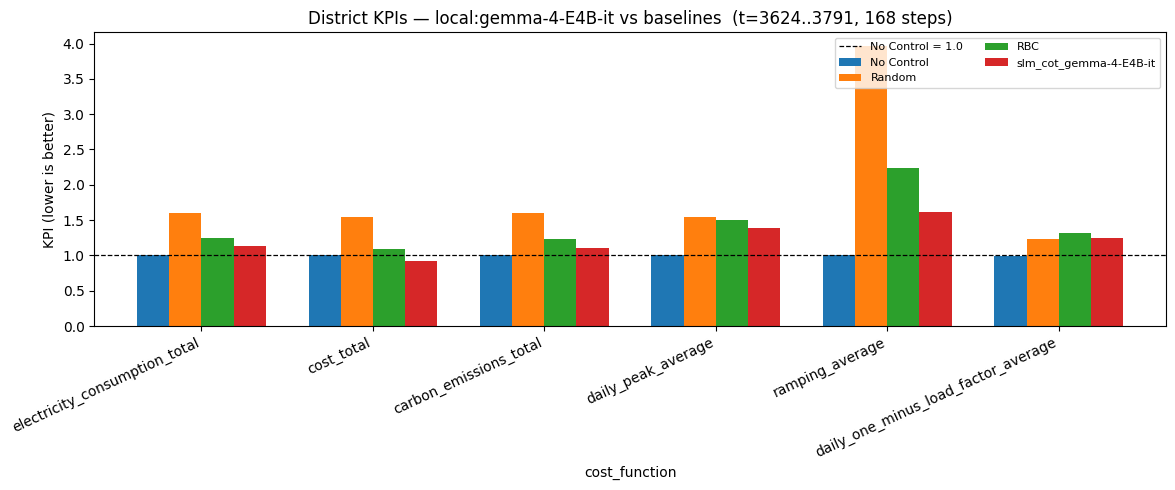

In [21]:
if present:
    ax = kpi_table.loc[present].plot(kind="bar", figsize=(12, 5), width=0.75)
    ax.axhline(1.0, color="k", ls="--", lw=0.9, label="No Control = 1.0")
    ax.set_ylabel("KPI (lower is better)")
    ax.set_title(
        f"District KPIs — {slm.label} vs baselines  "
        f"(t={WEEK_START}..{WEEK_START+WEEK_LEN-1}, {WEEK_LEN} steps)"
    )
    ax.legend(loc="upper right", fontsize=8, ncol=2)
    plt.xticks(rotation=25, ha="right")
    plt.tight_layout()
    plt.show()

## § 12 — Per-Agent Breakdown (α vs β)

In [22]:
def per_agent_summary(df: pd.DataFrame, agent_name: str, bldg_indices: list) -> dict:
    net_cols = [f"net{i}" for i in bldg_indices]
    r_cols   = [f"r{i}"   for i in bldg_indices]
    soc_cols = [f"soc{i}" for i in bldg_indices]
    a_cols   = [f"a{i}"   for i in bldg_indices]
    dist_net = df[net_cols].sum(axis=1)
    return {
        "agent":         agent_name,
        "buildings":     str(bldg_indices),
        "total_reward":  float(df[r_cols].sum().sum()),
        "mean_soc_pct":  float(df[soc_cols].mean().mean() * 100),
        "peak_net_kW":   float(dist_net.max()),
        "total_net_kWh": float(dist_net.sum()),
        "mean_action":   float(df[a_cols].values.mean()),
        "std_action":    float(df[a_cols].values.std()),
    }


agent_df = pd.DataFrame([
    per_agent_summary(slm_df, f"{slm.label} / α", AGENT_A_BUILDINGS),
    per_agent_summary(slm_df, f"{slm.label} / β", AGENT_B_BUILDINGS),
]).set_index("agent")

print("Per-agent breakdown — α (B0-2) vs β (B3-5)")
display(agent_df.round(4))

# Fallback counts
n_fb_a = sum(1 for r in slm_run["raw_log_a"] if r["fallback"])
n_fb_b = sum(1 for r in slm_run["raw_log_b"] if r["fallback"])
print(f"\nFallbacks: α={n_fb_a}/{WEEK_LEN}  β={n_fb_b}/{WEEK_LEN}  (target: 0)")

Per-agent breakdown — α (B0-2) vs β (B3-5)


,buildings,total_reward,mean_soc_pct,peak_net_kW,total_net_kWh,mean_action,std_action
agent,,,,,,,
local:gemma-4-E4B-it / α,"[0, 1, 2]",-888.9134,74.3509,13.7074,474.6114,0.0156,0.1667
local:gemma-4-E4B-it / β,"[3, 4, 5]",-1396.4975,72.8107,15.2247,805.0877,0.0100,0.1857



Fallbacks: α=0/168  β=0/168  (target: 0)


## § 13 — Diagnostics

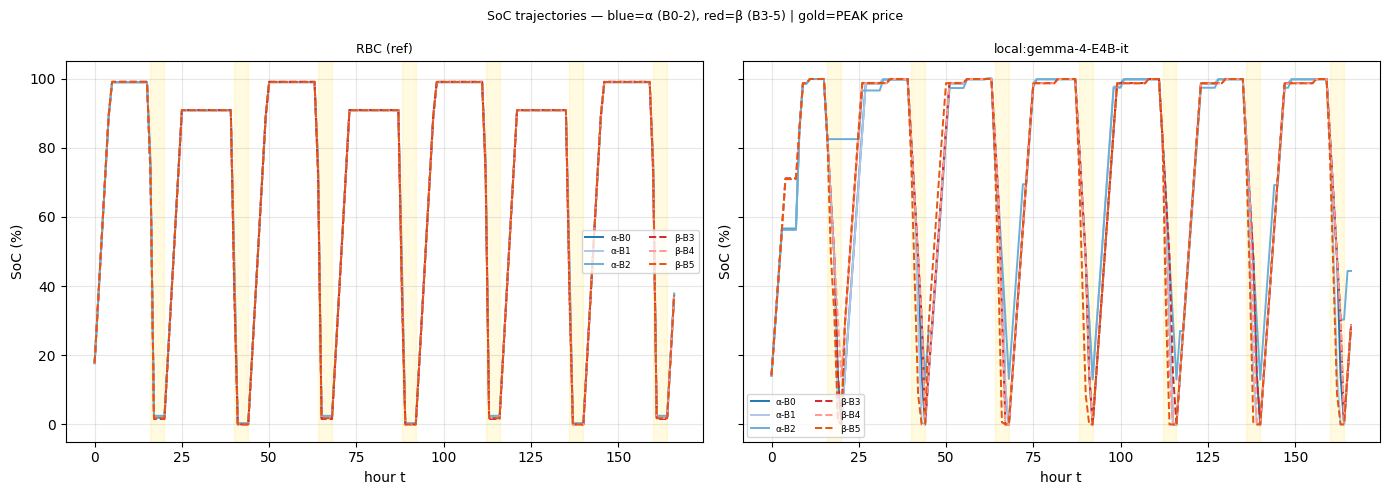

In [23]:
# 13.1  SoC trajectories — α in blue, β in red, PEAK price shaded gold
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

colors_a = ["#1f77b4", "#aec7e8", "#6baed6"]
colors_b = ["#d62728", "#ff9896", "#e6550d"]

for ax, (df_, label) in zip(axes, [(df_rbc, "RBC (ref)"), (slm_df, slm.label)]):
    for li, gi in enumerate(AGENT_A_BUILDINGS):
        ax.plot(df_["t"], df_[f"soc{gi}"] * 100,
                label=f"α-B{gi}", lw=1.4, color=colors_a[li])
    for li, gi in enumerate(AGENT_B_BUILDINGS):
        ax.plot(df_["t"], df_[f"soc{gi}"] * 100,
                label=f"β-B{gi}", lw=1.4, color=colors_b[li], ls="--")

    # Shade PEAK price hours
    peak_mask = (df_["price"] >= PRICE_PEAK_THRESHOLD).values
    in_peak, span_s = False, 0
    for im, is_peak in enumerate(peak_mask):
        if is_peak and not in_peak:
            span_s = im; in_peak = True
        elif not is_peak and in_peak:
            ax.axvspan(span_s, im - 1, color="gold", alpha=0.12); in_peak = False
    if in_peak:
        ax.axvspan(span_s, len(peak_mask) - 1, color="gold", alpha=0.12)

    ax.set_xlabel("hour t"); ax.set_ylabel("SoC (%)")
    ax.set_title(label, fontsize=9)
    ax.legend(ncol=2, fontsize=6.5); ax.grid(alpha=0.3)

plt.suptitle(
    "SoC trajectories — blue=α (B0-2), red=β (B3-5) | gold=PEAK price",
    fontsize=9,
)
plt.tight_layout()
plt.show()

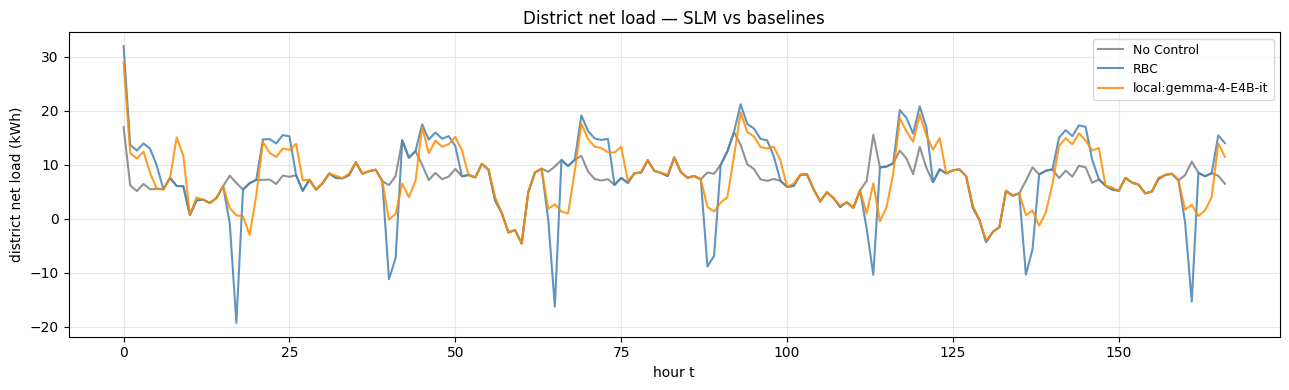

In [24]:
# 13.2  District net load comparison
fig, ax = plt.subplots(figsize=(13, 4))

for df_, lbl, color, ls in [
    (df_noop,   "No Control", "gray",        "-"),
    (df_rbc,    "RBC",        "steelblue",   "-"),
    (slm_df,    slm.label,   "darkorange",  "-"),
]:
    net = df_[[f"net{i}" for i in range(6)]].sum(axis=1)
    ax.plot(df_["t"], net, label=lbl, lw=1.5, color=color, ls=ls, alpha=0.85)

ax.set_xlabel("hour t")
ax.set_ylabel("district net load (kWh)")
ax.set_title("District net load — SLM vs baselines")
ax.legend(fontsize=9); ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [25]:
# 13.3  Sample raw responses — 2 timesteps, both agents
SHOW_STEPS = [10, 80]

log_a = slm_run["raw_log_a"]
log_b = slm_run["raw_log_b"]

for step_t in SHOW_STEPS:
    idx = next((i for i, r in enumerate(log_a) if r["t"] == step_t), None)
    if idx is None:
        continue
    print("═" * 70)
    print(f"t = {step_t}")
    print(f"\n── Agent α ──")
    print(f"State:\n{log_a[idx]['state_text']}")
    print(f"\nResponse (fallback={log_a[idx]['fallback']}):\n{log_a[idx]['raw']}")
    if idx < len(log_b):
        print(f"\n── Agent β ──")
        print(f"State:\n{log_b[idx]['state_text']}")
        print(f"\nResponse (fallback={log_b[idx]['fallback']}):\n{log_b[idx]['raw']}")
    print()

══════════════════════════════════════════════════════════════════════
t = 10

── Agent α ──
State:
Month 12, Fri 09:00  |  price=0.210 (LOW)  |  carbon=0.206 (MID)
Forecast:  price+6h=PEAK  price+12h=LOW  solar+6h=HIGH
Buildings:
  B0: SoC= 98.6%  load=0.75 kWh  last_net=+1.93 kWh  solar=HIGH
  B1: SoC= 98.5%  load=2.23 kWh  last_net=+1.96 kWh  solar=HIGH
  B2: SoC= 98.5%  load=1.03 kWh  last_net=+1.68 kWh  solar=HIGH

Response (fallback=False):
<thought>All batteries high; low price favors charging, but SoC limits action.</thought>
<action building=0>IDLE</action>
<action building=1>IDLE</action>
<action building=2>IDLE</action>

── Agent β ──
State:
Month 12, Fri 09:00  |  price=0.210 (LOW)  |  carbon=0.206 (MID)
Forecast:  price+6h=PEAK  price+12h=LOW  solar+6h=HIGH
Buildings:
  B0: SoC= 98.7%  load=1.37 kWh  last_net=+2.19 kWh  solar=HIGH
  B1: SoC= 98.6%  load=1.95 kWh  last_net=+1.52 kWh  solar=HIGH
  B2: SoC= 98.6%  load=1.43 kWh  last_net=+2.40 kWh  solar=HIGH

Response (fallb

In [26]:
# 13.4  Timing analysis — tokens generated per call, tokens/second
all_responses = (
    [r["raw"] for r in slm_run["raw_log_a"]]
    + [r["raw"] for r in slm_run["raw_log_b"]]
)
token_counts = [
    len(slm.tokenizer.encode(r, add_special_tokens=False))
    for r in all_responses if r
]

print(f"Total calls          : {len(all_responses)}")
print(f"Tokens generated/call: mean={np.mean(token_counts):.0f}  "
      f"min={min(token_counts)}  max={max(token_counts)}")
print(f"Total tokens         : {sum(token_counts):,}")

# Throughput from the realistic warmup (not a trivial 1-token response)
_warmup_toks = len(slm.tokenizer.encode(_resp, add_special_tokens=False))
_tok_per_s   = _warmup_toks / (_wt1 - _wt0) if (_wt1 - _wt0) > 0 else 0
print(f"Approx throughput    : {_tok_per_s:.0f} tokens/s  "
      f"({_tok_per_s * 60:.0f} tokens/min)")

# Fallback rate
all_fb = (
    [r["fallback"] for r in slm_run["raw_log_a"]]
    + [r["fallback"] for r in slm_run["raw_log_b"]]
)
print(f"Fallback rate        : {sum(all_fb)}/{len(all_fb)} "
      f"({100*sum(all_fb)/len(all_fb):.1f}%)  (target: 0%)")

Total calls          : 334
Tokens generated/call: mean=58  min=52  max=64
Total tokens         : 19,258
Approx throughput    : 4 tokens/s  (241 tokens/min)
Fallback rate        : 0/334 (0.0%)  (target: 0%)
